### Data to use
The data was shared throgth 
https://www.hydroshare.org/resource/6be754bf29cb488b815810c35f3f0ac9/

#### THREDDS Data Service
https://thredds.hydroshare.org/thredds/catalog/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/catalog.html

In [1]:
from mpasviewer import scvtmesh
import cartopy.crs as ccrs
from datetime import datetime

In [2]:
url_thredds = "https://thredds.hydroshare.org/thredds/catalog/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_out/catalog.html" ### New York
inidt = datetime(2021, 9, 1, 13); enddt = datetime(2021, 9, 2, 12) ## NYC

list_files = scvtmesh.get_thredds_list(url_thredds, date_start=inidt, date_end=enddt)

In [3]:
# list_files

In [4]:
mpasd = scvtmesh(grid_file = 'http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc',
                 diag_list = list_files)

In [5]:
# mpasd.dataset()
mpasd.dataset(load_variables=['rainnc', 'rainc', "u10","v10","t2m",'olrtoa','refl10cm_max',])

/Users/ss4338/mpasviewer/src/mpasviewer/main.py:101: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  outgrid = xr.open_mfdataset(allfls, combine='nested', concat_dim='Time', decode_cf=True, mask_and_scale=False)


Loaded grid_file dataset: http://thredds.hydroshare.org/thredds/dodsC/hydroshare/resources/6be754bf29cb488b815810c35f3f0ac9/data/contents/nyc_static/nyc.static.nc


In [6]:
mpasd.rain_rate()

In [7]:
dta = mpasd.load()

In [8]:
from earthcmap import escmap

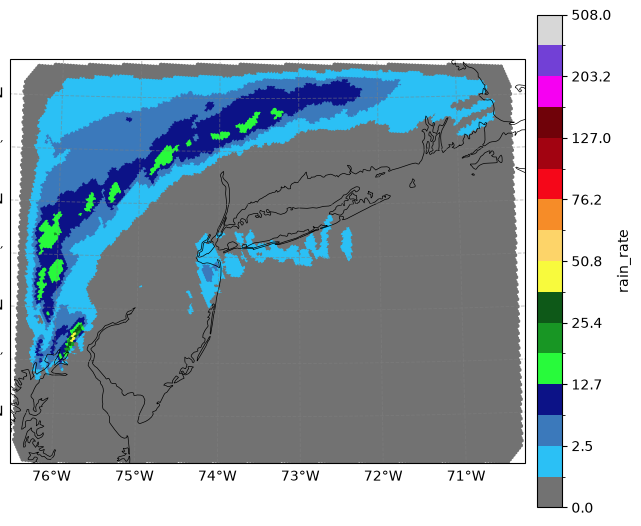

In [15]:
cmap, norm = escmap("nwps_qpe", units="mm")

mpasd.show(dta,var_name='rain_rate', time_index=5, figsize=(8,8), cmap = cmap, norm = norm,)

In [10]:
from ipywidgets import interact, Dropdown, SelectionSlider
from IPython.display import display, clear_output

In [11]:
mpas_vars = ['rainnc', 'rainc', "u10","v10","t2m",'olrtoa','refl10cm_max',]
times = sorted([str(x) for x in dta['time'].data.astype('datetime64[s]')])
num_steps = len(times)

In [12]:
def update_plot(variable, time_step):
    mpasd.show(dta, var_name = variable, time_index = time_step, figsize=(9,9))
    
# dropdown and slider widgets
variable_dropdown = Dropdown(options=mpas_vars, description='Variable:')
time_slider = SelectionSlider(
    options=times,
    value=times[5],
    description='Datetime:',
    layout={'width': '500px'},
    style={'description_width': 'initial'}
)

In [13]:
interact(update_plot, variable=variable_dropdown, time_step=time_slider)

interactive(children=(Dropdown(description='Variable:', options=('rainnc', 'rainc', 'u10', 'v10', 't2m', 'olrt…

<function __main__.update_plot(variable, time_step)>